In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
np.random.seed(42)
n = 1000

In [38]:
sqft = np.random.randint(800, 5000, n)
bedrooms = np.random.randint(1, 6, n)
noise = np.random.normal(0, 20000, n)
price = 50 * sqft + 30000 * bedrooms + 80000 + noise
price = price.astype(int)

In [39]:
df = pd.DataFrame({
    "price": price,
    "sqft": sqft,
    "bedrooms": bedrooms
})
print("Dataset shape:", df.shape)

Dataset shape: (1000, 3)


In [ ]:
df['sqft_bin'] = pd.cut(df['sqft'], bins=20)
avg_price_sqft = df.groupby('sqft_bin')['price'].mean()

/tmp/ipykernel_5293/2288299668.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_sqft = df.groupby('sqft_bin')['price'].mean()


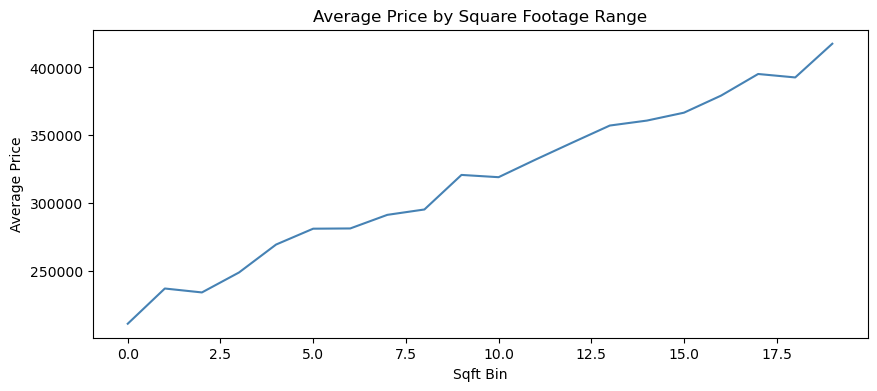

In [41]:
plt.figure(figsize=(10, 4))
plt.plot(range(len(avg_price_sqft)), avg_price_sqft.values, color='steelblue')
plt.title('Average Price by Square Footage Range')
plt.xlabel('Sqft Bin')
plt.ylabel('Average Price')
plt.show()

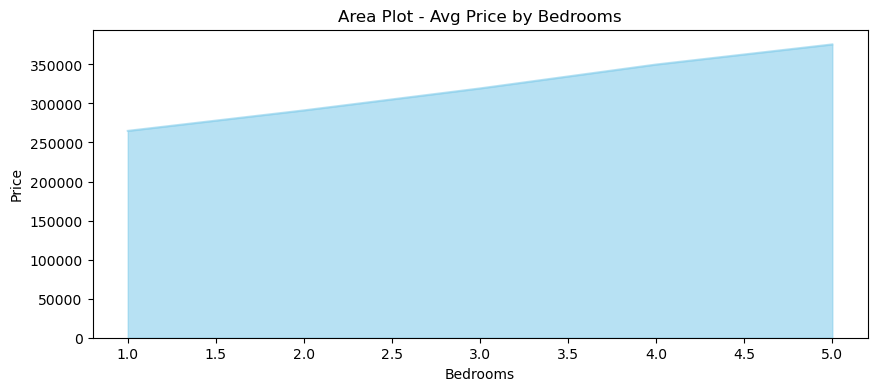

In [42]:
avg_price_bed = df.groupby('bedrooms')['price'].mean()
avg_price_bed.plot.area(figsize=(10, 4), color='skyblue', alpha=0.6)
plt.title('Area Plot - Avg Price by Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.show()

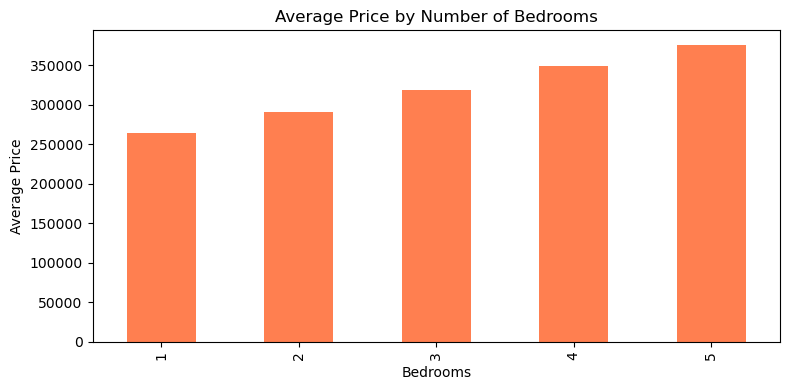

In [43]:
avg_price_bed = df.groupby('bedrooms')['price'].mean()
avg_price_bed.plot(kind='bar', figsize=(8, 4), color='coral')
plt.title('Average Price by Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()

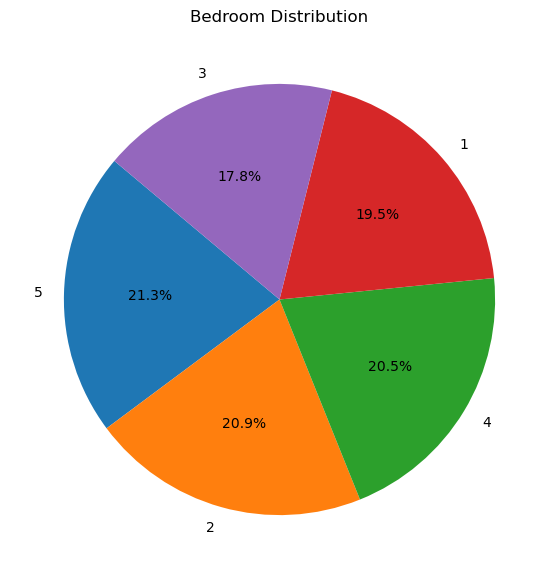

In [44]:
bedroom_counts = df['bedrooms'].value_counts().head(6)
plt.figure(figsize=(7, 7))
plt.pie(bedroom_counts, labels=bedroom_counts.index,
        autopct='%1.1f%%', startangle=140)
plt.title('Bedroom Distribution')
plt.show()

<Figure size 800x500 with 0 Axes>

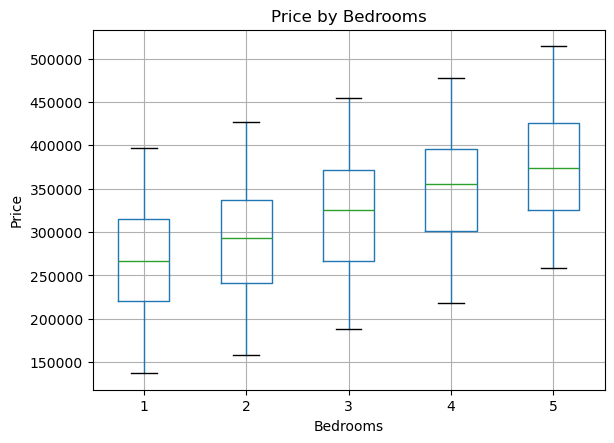

In [45]:
plt.figure(figsize=(8, 5))
df[df['bedrooms'].between(1, 6)].boxplot(
    column='price', by='bedrooms')
plt.title('Price by Bedrooms')
plt.suptitle('')
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.show()

Text(0.5, 1.0, 'Price Distribution')

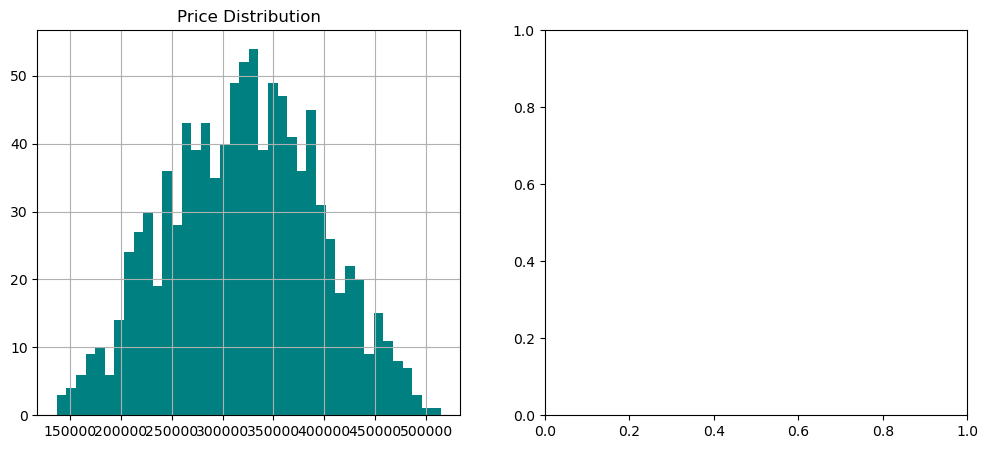

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['price'].hist(bins=40, ax=axes[0], color='teal')
axes[0].set_title('Price Distribution')

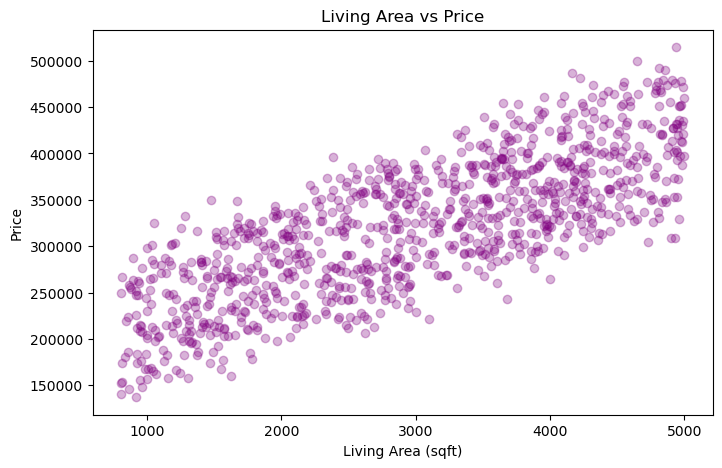

In [47]:
plt.figure(figsize=(8, 5))
plt.scatter(df['sqft'], df['price'],
            alpha=0.3, color='purple')
plt.title('Living Area vs Price')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price')
plt.show()

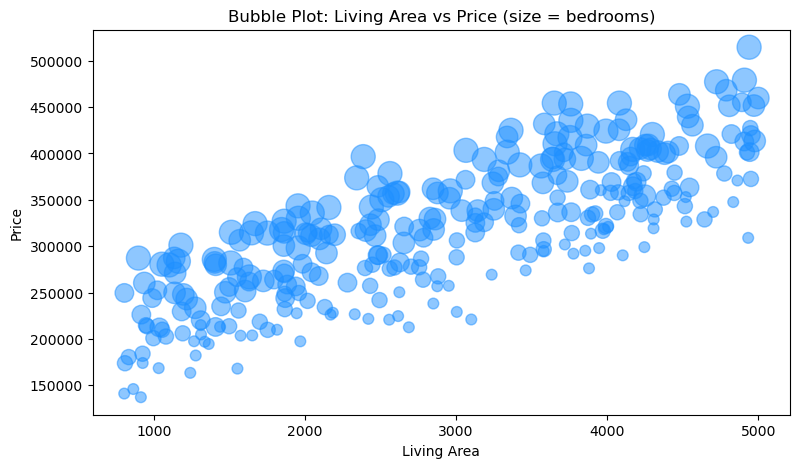

In [48]:
sample = df.sample(300, random_state=1)
plt.figure(figsize=(9, 5))
plt.scatter(sample['sqft'], sample['price'],
            s=sample['bedrooms'] * 60, alpha=0.5, color='dodgerblue')
plt.title('Bubble Plot: Living Area vs Price (size = bedrooms)')
plt.xlabel('Living Area')
plt.ylabel('Price')
plt.show()

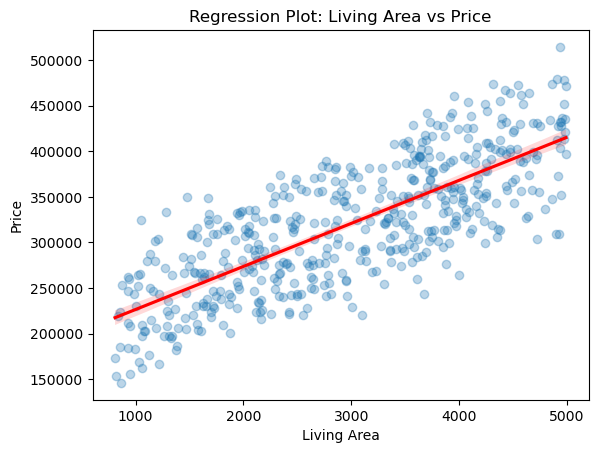

In [49]:
sample2 = df.sample(500, random_state=42)
sns.regplot(x='sqft', y='price', data=sample2,
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title('Regression Plot: Living Area vs Price')
plt.xlabel('Living Area')
plt.ylabel('Price')
plt.show()

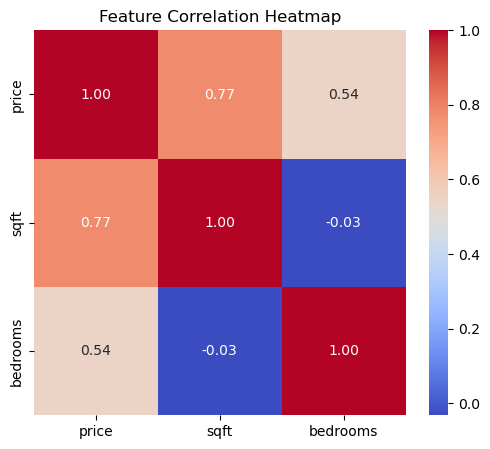

In [50]:
corr = df[['price', 'sqft', 'bedrooms']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [51]:
df.to_csv("/tmp/portland_housing_clean.csv", index=False)
print("Preprocessed data saved to /tmp/portland_housing_clean.csv")

Preprocessed data saved to /tmp/portland_housing_clean.csv


In [52]:
df.to_csv("/tmp/portland_housing_clean.csv", index=False)
print("Preprocessed data saved to /tmp/portland_housing_clean.csv")

Preprocessed data saved to /tmp/portland_housing_clean.csv


In [53]:
df.to_csv("/tmp/portland_housing_clean.csv", index=False)
print("Preprocessed data saved to /tmp/portland_housing_clean.csv")

Preprocessed data saved to /tmp/portland_housing_clean.csv


In [54]:
df.to_csv("/tmp/portland_housing_clean.csv", index=False)
print("Preprocessed data saved to /tmp/portland_housing_clean.csv")

Preprocessed data saved to /tmp/portland_housing_clean.csv


In [55]:
df.to_csv("/tmp/portland_housing_clean.csv", index=False)
print("Preprocessed data saved to /tmp/portland_housing_clean.csv")

Preprocessed data saved to /tmp/portland_housing_clean.csv


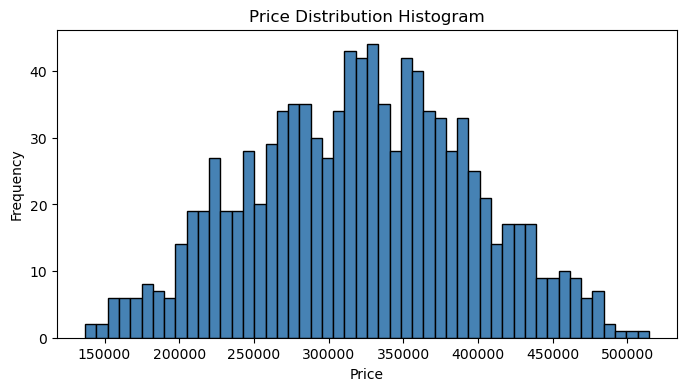

In [56]:
plt.figure(figsize=(8, 4))
plt.hist(df['price'], bins=50, color='steelblue', edgecolor='black')
plt.title('Price Distribution Histogram')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

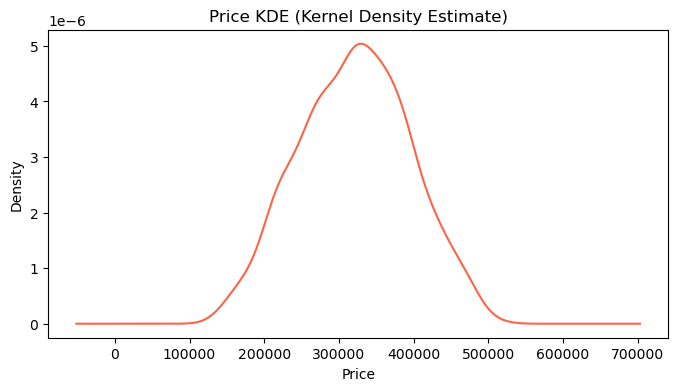

In [57]:
plt.figure(figsize=(8, 4))
df['price'].plot(kind='kde', color='tomato')
plt.title('Price KDE (Kernel Density Estimate)')
plt.xlabel('Price')
plt.show()

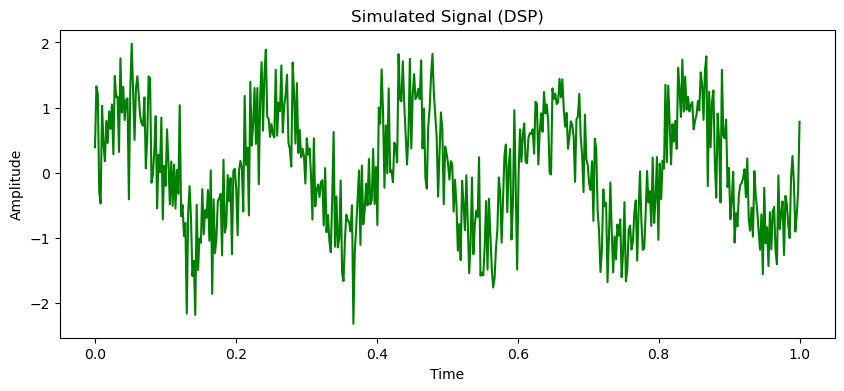

In [58]:
t = np.linspace(0, 1, 500)
signal = np.sin(2 * np.pi * 5 * t) + 0.5 * np.random.randn(500)
plt.figure(figsize=(10, 4))
plt.plot(t, signal, color='green')
plt.title('Simulated Signal (DSP)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

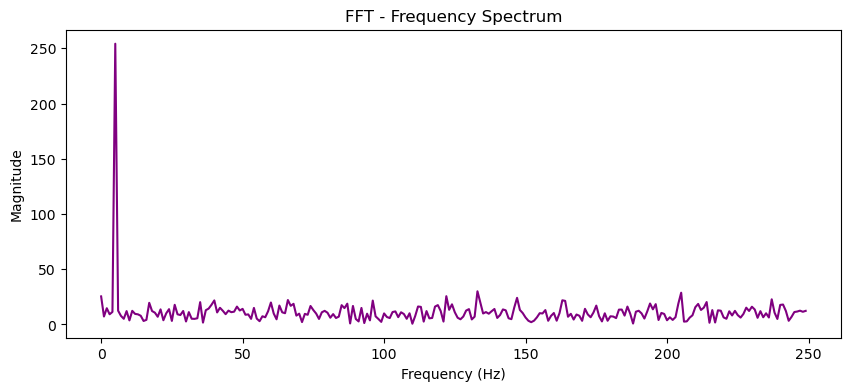

In [59]:
fft_vals = np.fft.fft(signal)
freqs = np.fft.fftfreq(len(signal), d=1/500)
plt.figure(figsize=(10, 4))
plt.plot(freqs[:250], np.abs(fft_vals[:250]), color='purple')
plt.title('FFT - Frequency Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.show()